In [43]:
import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [44]:
def visualize_12_bands(img_path):
    band_names = [
        "Coastal Aerosol", "Blue", "Green", "Red",
        "NIR", "SWIR 1", "SWIR 2", "QA Band",
        "Merit DEM", "Copernicus DEM", "ESA World Cover", "Water Occur. Probability"
    ]
    
    # Load multi-channel tiff
    image = tifffile.imread(img_path).astype(np.float32)
    
    # Ensure shape is (H, W, C) for analysis
    if image.shape[0] == 12:
        image = np.transpose(image, (1, 2, 0))
        
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for i in range(12):
        ax = axes.flat[i]
        band_data = image[:, :, i]
        
        # Min-max scaling for visualization purposes
        b_min, b_max = band_data.min(), band_data.max()
        scaled = (band_data - b_min) / (b_max - b_min + 1e-8)
        
        im = ax.imshow(scaled, cmap='viridis')
        ax.set_title(band_names[i], fontsize=10)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    plt.show()

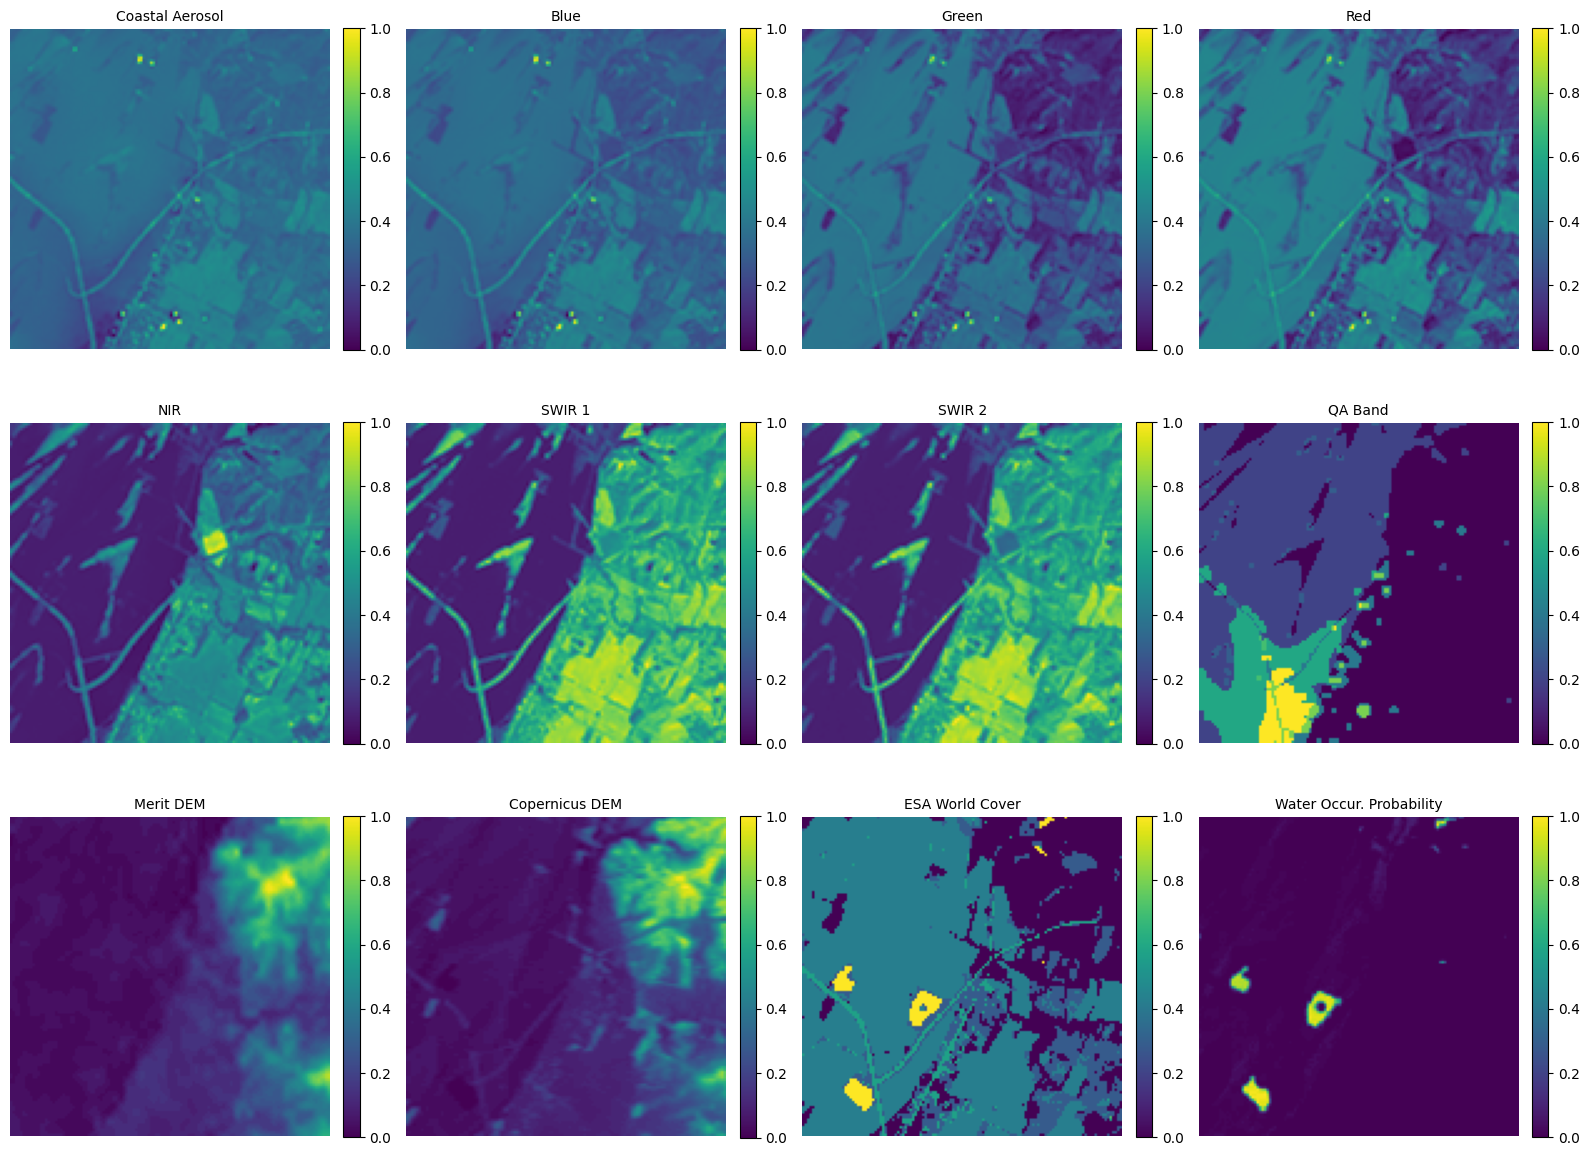

In [ ]:
visualize_12_bands("D:/Cellula/Week 2/data/images/100.tif")

In [46]:
def analyze_class_distribution(masks_dir, filenames):
    total_pixels = 0
    water_pixels = 0
    
    for fname in filenames:
        base_name = os.path.splitext(fname)[0]
        mask_path = os.path.join(masks_dir, f"{base_name}.png")
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            binary_mask = (mask > 127).astype(np.uint8) # Thresh standard 255 masks
            total_pixels += binary_mask.size
            water_pixels += np.sum(binary_mask)
            
    land_pixels = total_pixels - water_pixels
    print(f"Total Pixels: {total_pixels:,}")
    print(f"Land (Background) Pixels: {land_pixels:,} ({land_pixels/total_pixels*100:.2f}%)")
    print(f"Water (Positive) Pixels: {water_pixels:,} ({water_pixels/total_pixels*100:.2f}%)")
    print(f"Imbalance Ratio (Land:Water): {land_pixels / (water_pixels + 1e-8):.2f} : 1")

In [ ]:
analyze_class_distribution("D:/Cellula/Week 2/data/labels", ["100.tif"])

Total Pixels: 16,384
Land (Background) Pixels: 16,384 (100.00%)
Water (Positive) Pixels: 0 (0.00%)
Imbalance Ratio (Land:Water): 1638400000000.00 : 1
